## HW 4: Policy gradient
_Reference: based on Practical RL course by YSDA_

In this notebook you have to master Policy gradient Q-learning and apply it to familiar (and not so familiar) RL problems once again.

To get used to `gymnasium` package, please, refer to the [documentation](https://gymnasium.farama.org/introduction/basic_usage/).


In the end of the notebook, please, copy the functions you have implemented to the template file and submit it to the Contest.

In [167]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

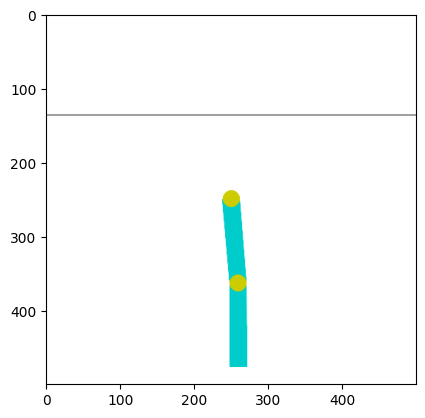

In [168]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape

plt.imshow(env.render())

In [169]:
import torch
import torch.nn as nn

In [170]:
class Actor(nn.Module):
  def __init__(self):
    super(Actor,self).__init__()
    self.l1=nn.Linear(6,40)
    self.l2=nn.Linear(40,3)
    self.log=nn.Sigmoid()
    self.sm=nn.Softmax()
  def forward(self,x):
    out=self.l1(x)
    out=self.log(out)
    out=self.l2(out)
    return out

In [171]:
class Critic(nn.Module):
  def __init__(self):
    super(Critic,self).__init__()
    self.l1=nn.Linear(6,40)
    self.l2=nn.Linear(40,1)
    self.log=nn.Sigmoid()
    self.relu=nn.ReLU()
  def forward(self,x):
    out=self.l1(x)
    out=self.relu(out)
    out=self.l2(out)
    out=self.relu(out)
    return out

In [172]:
def predict_probs(states, actor):
    probs = torch.softmax(actor(torch.from_numpy(states).type(torch.FloatTensor)),dim=-1)

    return probs.detach().numpy()

In [173]:
def predict_values(states, critic):
  values = critic(values)
  return values.detach().numpy()

In [174]:
def generate_session(env, t_max=1000):
    states, actions, rewards = [], [], []
    s, info = env.reset()

    for t in range(t_max):
        action_probs = predict_probs(np.array([s]),actor)[0]
        a = np.random.choice(n_actions, p=action_probs)
        new_s, r, done, truncated, info = env.step(a)
        states.append(s)
        actions.append(a)
        rewards.append(r)

        s = new_s
        if done:
            break

    return states, actions, rewards

In [175]:
def get_cumulative_rewards(rewards,  # rewards at each step
                           gamma=0.99,  # discount for reward
                           n=40):
    cumulative_rewards = np.zeros(len(rewards))
    G_t=0
    cumulative_rewards[-1]=rewards[-1]
    for i in range(len(rewards)):
      cumulative_rewards[-1-i]=rewards[-i-1]+gamma*cumulative_rewards[-1-i]-(gamma**n)*cumulative_rewards[min(-1-i+n,0)]

    return cumulative_rewards

### Loss function and updates

We now need to define objective and update over policy gradient.

Our objective function is

$$ J \approx  { 1 \over N } \sum_{s_i,a_i} G(s_i,a_i) $$

REINFORCE defines a way to compute the gradient of the expected reward with respect to policy parameters. The formula is as follows:

$$ \nabla_\theta \hat J(\theta) \approx { 1 \over N } \sum_{s_i, a_i} \nabla_\theta \log \pi_\theta (a_i \mid s_i) \cdot G_t(s_i, a_i) $$

We can abuse PyTorch's capabilities for automatic differentiation by defining our objective function as follows:

$$ \hat J(\theta) \approx { 1 \over N } \sum_{s_i, a_i} \log \pi_\theta (a_i \mid s_i) \cdot G_t(s_i, a_i) $$

When you compute the gradient of that function with respect to network weights $\theta$, it will become exactly the policy gradient.

Final loss should also include the entropy regularization term $H(\pi_\theta (a_i \mid s_i))$ to enforce the exploration:

$$
L = -\hat J(\theta) - \lambda H(\pi_\theta (a_i \mid s_i)),
$$
where $\lambda$ is the `entropy_coef`.

In [176]:
def to_one_hot(y_tensor, ndims):
    y_tensor = y_tensor.type(torch.LongTensor).view(-1, 1)
    y_one_hot = torch.zeros(
        y_tensor.size()[0], ndims).scatter_(1, y_tensor, 1)
    return y_one_hot

In [177]:
n_actions = 3;
def get_loss(logits, actions, rewards, expected_rewards, n_actions=n_actions, gamma=0.99, entropy_coef=1e-2):
    actions = torch.tensor(actions, dtype=torch.int32)
    cumulative_returns = np.array(get_cumulative_rewards(rewards, gamma) - expected_rewards.detach().numpy())
    cumulative_returns = torch.tensor(cumulative_returns, dtype=torch.float32)

    probs = torch.softmax(logits,dim=-1)

    log_probs = torch.log_softmax(logits,dim=-1)
    log_probs_for_actions = torch.sum(log_probs*to_one_hot(actions,n_actions),dim=1) # [batch,]
    J_hat = torch.mean(log_probs_for_actions*cumulative_returns)  # a number

    entropy = -1*torch.sum(probs*log_probs,dim=1).mean()
    loss = -J_hat-entropy_coef*entropy

    return loss

In [178]:
import torch.nn.functional as F

In [179]:
actor=Actor()
critic=Critic()

In [180]:
actor_optimizer = torch.optim.Adam(actor.parameters(), 1e-3)
critic_optimizer = torch.optim.Adam(critic.parameters(), 1e-3)

def train_on_session(states, actions, rewards, gamma=0.99, entropy_coef=1e-2):
    states = torch.tensor(states, dtype=torch.float32)
    logits = actor(states)
    # cast everything into torch tensors
    expected_rewards=critic(states)
    actor_loss = get_loss(logits, actions, rewards, expected_rewards, n_actions=n_actions, gamma=gamma, entropy_coef=entropy_coef)
    critic_loss = F.mse_loss(expected_rewards,torch.tensor(rewards,requires_grad=True).view(len(rewards),1))#torch.pow((expected_rewards-torch.tensor(rewards,requires_grad=True).view(len(rewards),1)),2)
    # Gradient descent step
    actor_loss.backward()
    critic_loss.backward()
    actor_optimizer.step()
    actor_optimizer.zero_grad()
    critic_optimizer.step()
    critic_optimizer.zero_grad()

    # technical: return session rewards to print them later
    return np.sum(rewards)

## Bonus part (no points, just for the interested ones)

Try solving the `Acrobot-v1` environment. It is more complex than regular `CartPole-v1`, so the default Policy Gradient (REINFORCE) algorithm might not work. Maybe the baseline idea could help...

![Acrobot](https://gymnasium.farama.org/_images/acrobot.gif)


In [181]:
a=torch.tensor(np.arange(20)).view(20,1).squeeze()
b=torch.tensor(np.zeros(20)).view(20,1).squeeze()
F.mse_loss(a,b,reduction='none')

tensor([  0.,   1.,   4.,   9.,  16.,  25.,  36.,  49.,  64.,  81., 100., 121.,
        144., 169., 196., 225., 256., 289., 324., 361.], dtype=torch.float64)

In [ ]:
generate_session(env)

In [182]:
for i in range(500):
    rewards = [train_on_session(*generate_session(env), entropy_coef=1e-3) for _ in range(100)]  # generate new sessions

    print("mean reward:%.3f" % (np.mean(rewards)))

    if np.mean(rewards) > -100:
        print("You Win!")  # but you can train even further
        break

mean reward:-953.330
mean reward:-985.640
mean reward:-994.140
mean reward:-1000.000


KeyboardInterrupt: 